<a href="https://colab.research.google.com/github/SemalDeSilva/TEAI/blob/Shavinda-G.M.V-IT22224248/one.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
print(os.listdir("/content/drive"))

['MyDrive', '.shortcut-targets-by-id', '.Trash-0', '.Encrypted']


In [6]:
import cv2
import numpy as np
import pandas as pd
from pathlib import Path

# -------------------------------------------------
# Leaf segmentation
# -------------------------------------------------
def segment_leaf(img_bgr):
    """
    Isolate the leaf from a light/white background
    using HSV color thresholding + morphology.
    Returns a binary mask (255 = leaf, 0 = background)
    """
    # Convert BGR image to HSV (better for color separation)
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)

    # Green color range (tunable later)
    # H: hue, S: saturation, V: value (brightness)
    lower_green = np.array([35, 40, 40], dtype=np.uint8)
    upper_green = np.array([90, 255, 255], dtype=np.uint8)

    # Initial mask: pixels that look green
    mask = cv2.inRange(hsv, lower_green, upper_green)

    # Remove small noise (opening)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=1)

    # Fill small holes inside the leaf (closing)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Keep only the largest connected component (assumed to be the leaf)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)

    if num_labels <= 1:
        # No leaf found
        return np.zeros(mask.shape, dtype=np.uint8)

    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    leaf_mask = np.where(labels == largest_label, 255, 0).astype(np.uint8)

    return leaf_mask


# -------------------------------------------------
# Feature computation
# -------------------------------------------------
def compute_features(img_bgr, leaf_mask):
    """
    Compute quality-related features from the leaf region.
    """
    feats = {}

    # Count how many pixels belong to the leaf
    leaf_pixels = np.count_nonzero(leaf_mask)
    feats["leaf_area_px"] = int(leaf_pixels)

    # Safety check: segmentation failed or leaf too small
    if leaf_pixels < 500:
        feats.update({
            "bbox_w": 0, "bbox_h": 0, "aspect_ratio": 0.0,
            "green_mean": 0.0, "green_std": 0.0, "green_ratio": 0.0,
            "damage_ratio": 0.0, "defect_count": 0, "max_defect_area_ratio": 0.0,
            "edge_roughness": 0.0
        })
        return feats

    # -------------------------------
    # Shape & size features
    # -------------------------------
    ys, xs = np.where(leaf_mask > 0)
    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    bbox_w = (x2 - x1 + 1)
    bbox_h = (y2 - y1 + 1)

    feats["bbox_w"] = int(bbox_w)
    feats["bbox_h"] = int(bbox_h)
    feats["aspect_ratio"] = float(bbox_w / max(1, bbox_h))

    # -------------------------------
    # Freshness / green color features
    # -------------------------------
    g_channel = img_bgr[:, :, 1]
    g_vals = g_channel[leaf_mask > 0]

    feats["green_mean"] = float(np.mean(g_vals))
    feats["green_std"]  = float(np.std(g_vals))

    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    H, S, V = hsv[:, :, 0], hsv[:, :, 1], hsv[:, :, 2]

    # Green pixels inside leaf
    green_pixels = (
        (H >= 35) & (H <= 90) &
        (S >= 40) & (V >= 40) &
        (leaf_mask > 0)
    )

    feats["green_ratio"] = float(np.count_nonzero(green_pixels) / leaf_pixels)

    # -------------------------------
    # Damage / defect features
    # -------------------------------
    # Damage = inside leaf but not green AND dark or low saturation
    not_green = (~green_pixels) & (leaf_mask > 0)
    dark_or_low_sat = ((V < 80) | (S < 50)) & (leaf_mask > 0)

    damage_mask = (not_green & dark_or_low_sat).astype(np.uint8) * 255

    damaged_pixels = np.count_nonzero(damage_mask)
    feats["damage_ratio"] = float(damaged_pixels / leaf_pixels)

    num, lab, stats, _ = cv2.connectedComponentsWithStats(damage_mask, connectivity=8)

    if num <= 1:
        feats["defect_count"] = 0
        feats["max_defect_area_ratio"] = 0.0
    else:
        areas = stats[1:, cv2.CC_STAT_AREA]
        feats["defect_count"] = int(len(areas))
        feats["max_defect_area_ratio"] = float(np.max(areas) / leaf_pixels)

    # -------------------------------
    # Edge roughness (structural quality)
    # -------------------------------
    contours, _ = cv2.findContours(leaf_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        c = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(c)
        peri = cv2.arcLength(c, True)

        # Roughness proxy (1 = smooth, higher = rougher)
        feats["edge_roughness"] = float((peri * peri) / (4.0 * np.pi * max(area, 1e-6)))
    else:
        feats["edge_roughness"] = 0.0

    return feats


# -------------------------------------------------
# Run on a folder of images
# -------------------------------------------------
def run_folder(image_root, out_csv="features.csv"):
    """
    Iterate through all images in image_root,
    extract features, and save to CSV.
    """
    image_root = Path(image_root)
    rows = []

    exts = {".jpg", ".jpeg", ".png", ".webp"}

    for img_path in sorted(image_root.rglob("*")):
        if img_path.suffix.lower() not in exts:
            continue

        img = cv2.imread(str(img_path))
        if img is None:
            continue

        leaf_mask = segment_leaf(img)
        feats = compute_features(img, leaf_mask)
        feats["filename"] = str(img_path)

        rows.append(feats)

    df = pd.DataFrame(rows)
    df.to_csv(out_csv, index=False)
    print("Saved features to:", out_csv)
    print("Total images processed:", len(df))


In [7]:
DATASET_PATH = "/content/drive/MyDrive/Tea/all_images"
run_folder(DATASET_PATH, out_csv="tea_leaf_features.csv")


Saved features to: tea_leaf_features.csv
Total images processed: 819


In [8]:
import pandas as pd

df = pd.read_csv("tea_leaf_features.csv")  # if saved in current runtime
# If saved to Drive, use the full path, e.g. "/content/gdrive/MyDrive/.../tea_leaf_features.csv"

print("Rows:", len(df))
print(df.head())
print("\nMissing values:\n", df.isna().sum())
print("\nBasic stats:\n", df.describe(include="all"))


Rows: 819
   leaf_area_px  bbox_w  bbox_h  aspect_ratio  green_mean  green_std  \
0        686375     785    1672      0.469498   56.917092  16.025522   
1        691251     925    1608      0.575249   85.701710  14.048046   
2        659403    1773     694      2.554755   57.704372  18.024909   
3        686269    1577     674      2.339763   85.874956  18.533104   
4        481652     606    1528      0.396597   68.031737  17.765548   

   green_ratio  damage_ratio  defect_count  max_defect_area_ratio  \
0     0.974017      0.024568          1180               0.000733   
1     0.969662      0.016271           690               0.000353   
2     0.967452      0.031339          1408               0.000613   
3     0.990087      0.006729           276               0.000640   
4     0.980936      0.017683           613               0.000704   

   edge_roughness                                           filename  
0        3.555002  /content/drive/MyDrive/Tea/all_images/WIN_2025...  


In [9]:
df_clean = df[
    (df["leaf_area_px"] >= 500) &
    (df["green_ratio"] > 0)
].copy()

print("Original:", len(df))
print("Kept:", len(df_clean))
print("Removed:", len(df) - len(df_clean))


Original: 819
Kept: 817
Removed: 2


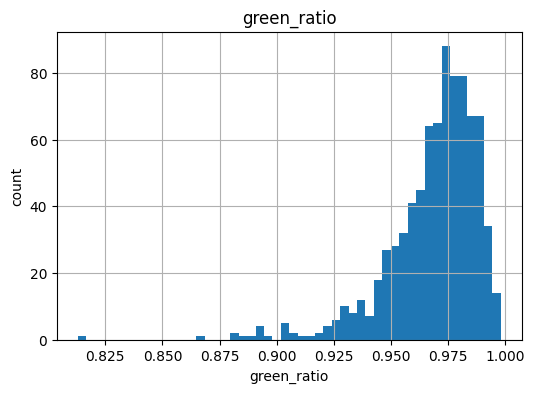

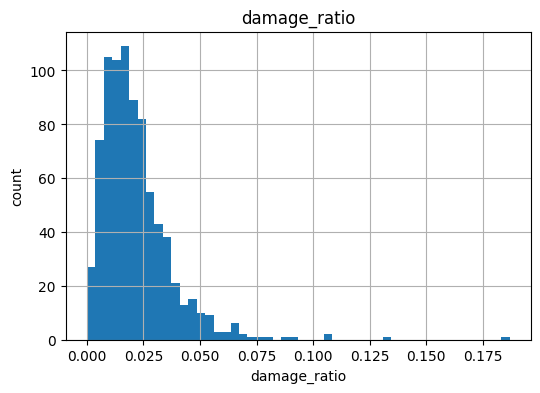

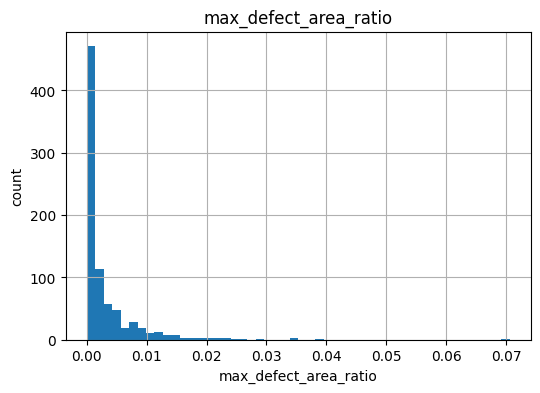

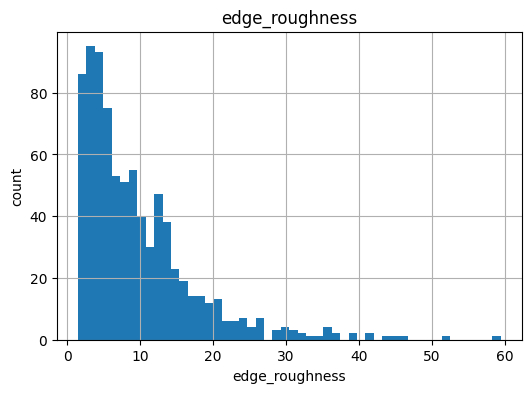

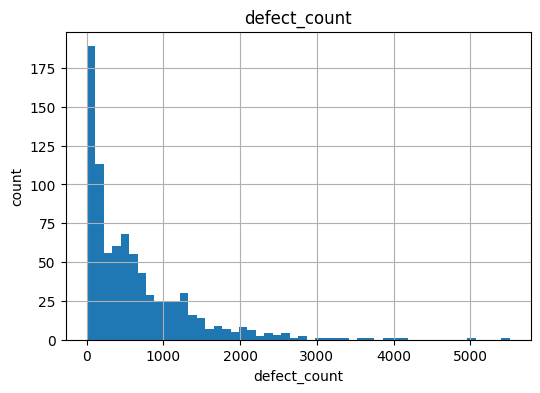

In [10]:
import matplotlib.pyplot as plt

features_to_plot = [
    "green_ratio",
    "damage_ratio",
    "max_defect_area_ratio",
    "edge_roughness",
    "defect_count"
]

for f in features_to_plot:
    plt.figure(figsize=(6,4))
    df_clean[f].hist(bins=50)
    plt.title(f)
    plt.xlabel(f)
    plt.ylabel("count")
    plt.show()


In [11]:
# Remove failed segmentations
df_clean = df[
    (df["leaf_area_px"] >= 500) &
    (df["green_ratio"] > 0)
].copy()

print("Original rows:", len(df))
print("Kept rows:", len(df_clean))
print("Removed rows:", len(df) - len(df_clean))


Original rows: 819
Kept rows: 817
Removed rows: 2


In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

feature_cols = [
    "leaf_area_px", "aspect_ratio",
    "green_ratio", "green_mean", "green_std",
    "damage_ratio", "defect_count", "max_defect_area_ratio",
    "edge_roughness"
]

X = df_clean[feature_cols].values
X_scaled = StandardScaler().fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_clean["cluster"] = kmeans.fit_predict(X_scaled)

print(df_clean["cluster"].value_counts())

cluster_summary = df_clean.groupby("cluster")[feature_cols].mean().round(4)
cluster_summary


cluster
0    437
2    225
1    155
Name: count, dtype: int64


,leaf_area_px,aspect_ratio,green_ratio,green_mean,green_std,damage_ratio,defect_count,max_defect_area_ratio,edge_roughness
cluster,,,,,,,,,
0,440173.4050,1.1492,0.9755,78.4557,17.6871,0.0137,361.6888,0.0018,6.6600
1,70304.0645,1.1144,0.9478,73.2952,20.1264,0.0420,156.6968,0.0102,8.3936
2,998610.3067,1.4040,0.9695,70.6342,20.1926,0.0225,1444.9467,0.0008,16.0936
